In [1]:
#!/usr/bin/env python
# coding: utf-8

# In[23]:


import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import os
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns


# In[11]:


# I don't know if we can use the GPUs on DSMLP to utilize the CUDA function of Pytorch
# So do not set epoch too high in order to have a faster training process.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# In[12]:


# create varaibles that holds a dataframe
cwd = os.getcwd()
data_dir = os.path.join(cwd, "Data/")
data_files = [f for f in os.listdir(str(data_dir)) if f.endswith('csv')]

data_train_name = [f for f in data_files if 'TRAIN' in f]
data_test_name = [f for f in data_files if 'TEST' in f]
data_NPML_name = [f for f in data_files if 'NPML' in f]
data_NPML_cut_name = [f for f in data_files if 'npml_cut' in f]

train_df = pd.read_csv(os.path.join(data_dir,data_train_name[0]))
test_df = pd.read_csv(os.path.join(data_dir,data_test_name[0]))
NPML_df = pd.read_csv(os.path.join(data_dir,data_NPML_name[0]))

NPML_cut_id = np.array(pd.read_csv(os.path.join(data_dir,data_NPML_cut_name[0]))['id'])
NPML_cut_df = NPML_df[NPML_df['id'].isin(NPML_cut_id)]








Using device: cpu


In [2]:
train_df = train_df.dropna()
test_df = test_df.dropna()
NPML_df = NPML_df.dropna()
NPML_cut_df = NPML_cut_df.dropna()


# feature selection and renaming

def manipulate_cols(df):
    boolean_col = ['highavse','lowavse','truedcr','lq']
    useless_col = ['tdrift50','tdrift10']
    new_df = df.drop(columns=boolean_col+['id']+useless_col)
    new_df.columns = [col.strip().replace(' ','_') for col in new_df.columns]
    return new_df

train_df = manipulate_cols(train_df)
test_df = manipulate_cols(test_df)
NPML_df = NPML_df.drop(columns=['tdrift50','tdrift10','id'])
NPML_cut_df = NPML_cut_df.drop(columns=['tdrift50','tdrift10','id'])




# Reshaping for consistency
X_train = train_df.drop(columns=['energylabel']).values
X_test = test_df.drop(columns=['energylabel']).values
y_train = train_df['energylabel'].values.reshape(-1,1)
y_test = test_df['energylabel'].values.reshape(-1,1)
X_NPML = NPML_df.values
X_NPML_cut = NPML_cut_df.values


In [21]:
#####################################################################################
# Extremely Important: REMOVE "pass" and UNCOMMENT the codes below to RUN it !!!!!  #
#####################################################################################

#---------------------------------------------------------------------------
# NaN Will Ruin the NN! So make sure it desn't contain any NaN in any corner!
#---------------------------------------------------------------------------

"""
features = [
    'tdrift', 'rea', 'dcr', 'peakindex', 'peakvalue', 'tailslope',
    'currentamp', 'lfpr', 'lq80', 'areagrowthrate', 'inflection_point',
    'risingedgeslope'
]
print(train_df[features].std())
print("Any NaNs in X_train?", np.isnan(X_train).any())
print("Any NaNs in X_test?", np.isnan(X_test).any())
print('\n')
print(train_df.isnull().sum())
print(test_df.isnull().sum())
"""
pass


# In[14]:


# Standardization

scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)
X_NPML = scaler_X.transform(X_NPML)
X_NPML_cut = scaler_X.transform(X_NPML_cut)

scaler_y = StandardScaler() # VERY IMPORTANT! We also need to transform it back to original after prediction!
y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)


# In[15]:


# Convert to Pytorch Tensor
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

X_NPML_tensor = torch.tensor(X_NPML, dtype=torch.float32)
X_NPML_cut_tensor = torch.tensor(X_NPML_cut, dtype=torch.float32)


# In[16]:


# Define dataloader

class NPDL(Dataset): # Neutrino Physics Deep Learning
    def __init__(self,X,y):
        self.X = X
        self.y = y
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self,idx):
        return self.X[idx], self.y[idx]
    
train_NPDL = NPDL(X_train_tensor,y_train_tensor)
test_NPDL = NPDL(X_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_NPDL, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_NPDL, batch_size=batch_size, shuffle=False)


# In[17]:


# Public Static int main!

class SuperPredictor(nn.Module):
    def __init__(self, input_size):
        super(SuperPredictor, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)  
        self.out = nn.Linear(16, 1)
        
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))  
        x = self.out(x)
        return x
    
input_size = X_train.shape[1]
model = SuperPredictor(input_size).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


    


# In[20]:




In [15]:
# Set epoch to 100 is good, but my computer is trash. DSMLP with c8m32 is even 10x slower than my laptop :)
num_epochs = 20 

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
    
    train_loss = running_loss / len(train_NPDL)
    
    model.eval()
    with torch.no_grad():
        ######################################################################################
        # Evaluate on test set, only for tuning things like learning rates and batchsizes.    #
        ######################################################################################
        test_predictions = model(X_test_tensor)
        test_loss_val = criterion(test_predictions, y_test_tensor).item()
        
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Test Loss(For tuning): {test_loss_val:.4f}")




Epoch [1/20] Train Loss: 0.0072, Test Loss(For tuning): 0.0052
Epoch [2/20] Train Loss: 0.0049, Test Loss(For tuning): 0.0049
Epoch [3/20] Train Loss: 0.0044, Test Loss(For tuning): 0.0043
Epoch [4/20] Train Loss: 0.0041, Test Loss(For tuning): 0.0042
Epoch [5/20] Train Loss: 0.0040, Test Loss(For tuning): 0.0044
Epoch [6/20] Train Loss: 0.0039, Test Loss(For tuning): 0.0045
Epoch [7/20] Train Loss: 0.0038, Test Loss(For tuning): 0.0041
Epoch [8/20] Train Loss: 0.0037, Test Loss(For tuning): 0.0039
Epoch [9/20] Train Loss: 0.0036, Test Loss(For tuning): 0.0042
Epoch [10/20] Train Loss: 0.0035, Test Loss(For tuning): 0.0042
Epoch [11/20] Train Loss: 0.0035, Test Loss(For tuning): 0.0043
Epoch [12/20] Train Loss: 0.0035, Test Loss(For tuning): 0.0041
Epoch [13/20] Train Loss: 0.0034, Test Loss(For tuning): 0.0039
Epoch [14/20] Train Loss: 0.0034, Test Loss(For tuning): 0.0038
Epoch [15/20] Train Loss: 0.0033, Test Loss(For tuning): 0.0037
Epoch [16/20] Train Loss: 0.0033, Test Loss(For t

In [5]:
model.eval()
with torch.no_grad():
    X_test_device = X_test_tensor.to(device)
    y_test_device = y_test_tensor.to(device)
    predictions = model(X_test_device)
    
    final_test_loss = criterion(predictions, y_test_device).item()
    print(f"Final Test MSE (scaled): {final_test_loss:.4f}")


predictions_np = predictions.cpu().numpy()  
y_test_np      = y_test_device.cpu().numpy()

predictions_original = scaler_y.inverse_transform(predictions_np)
y_test_original      = scaler_y.inverse_transform(y_test_np)

MSE = mean_squared_error(y_test_original, predictions_original)
MAE = mean_absolute_error(y_test_original, predictions_original)
r2  = r2_score(y_test_original, predictions_original)

print(f"Final Results on Test Data:")
print(f"MSE: {MSE:.4f}")
print(f"MAE: {MAE:.4f}")
print(f"R^2: {r2:.4f}")

Final Test MSE (scaled): 0.0036
Final Results on Test Data:
MSE: 1622.3000
MAE: 10.4148
R^2: 0.9964


In [6]:
predictions_original

array([[1169.4594 ],
       [ 849.7664 ],
       [ 592.86115],
       ...,
       [ 334.113  ],
       [ 160.9635 ],
       [ 208.72241]], dtype=float32)

In [16]:
model.eval()
with torch.no_grad():
    X_NPML_device = X_NPML_tensor.to(device)
    X_NPML_cut_device = X_NPML_cut_tensor.to(device)
    predictions_NPML = model(X_NPML_device)
    predictions_NPML_cut = model(X_NPML_cut_device)



predictions_NPML_np = predictions_NPML.cpu().numpy()  
predictions_NPML_cut_np = predictions_NPML_cut.cpu().numpy() 

predictions_NPML_original = scaler_y.inverse_transform(predictions_NPML_np)
predictions_NPML_cut_original = scaler_y.inverse_transform(predictions_NPML_cut_np)


In [65]:
# For Visualization
y_test_and_train = np.concatenate((train_df['energylabel'].values,test_df['energylabel'].values))
y_test_and_train_and_NPML = np.concatenate((predictions_NPML_original.reshape(-1),y_test_and_train))


trainDF_for_plot = pd.read_csv(os.path.join(data_dir,data_train_name[0]))
testDF_for_plot = pd.read_csv(os.path.join(data_dir,data_test_name[0]))
trainDF_for_plot_cut_energy = np.array(trainDF_for_plot[(trainDF_for_plot[['highavse', 'lowavse', 'truedcr', 'lq']]).all(axis=1)]['energylabel'])
testDF_for_plot_cut_energy = np.array(testDF_for_plot[(testDF_for_plot[['highavse', 'lowavse', 'truedcr', 'lq']]).all(axis=1)]['energylabel'])
test_and_train_cut = np.concatenate((testDF_for_plot_cut_energy,trainDF_for_plot_cut_energy))


In [66]:
#np.save("predictions_NPML_cut.npy", predictions_NPML_cut_original)


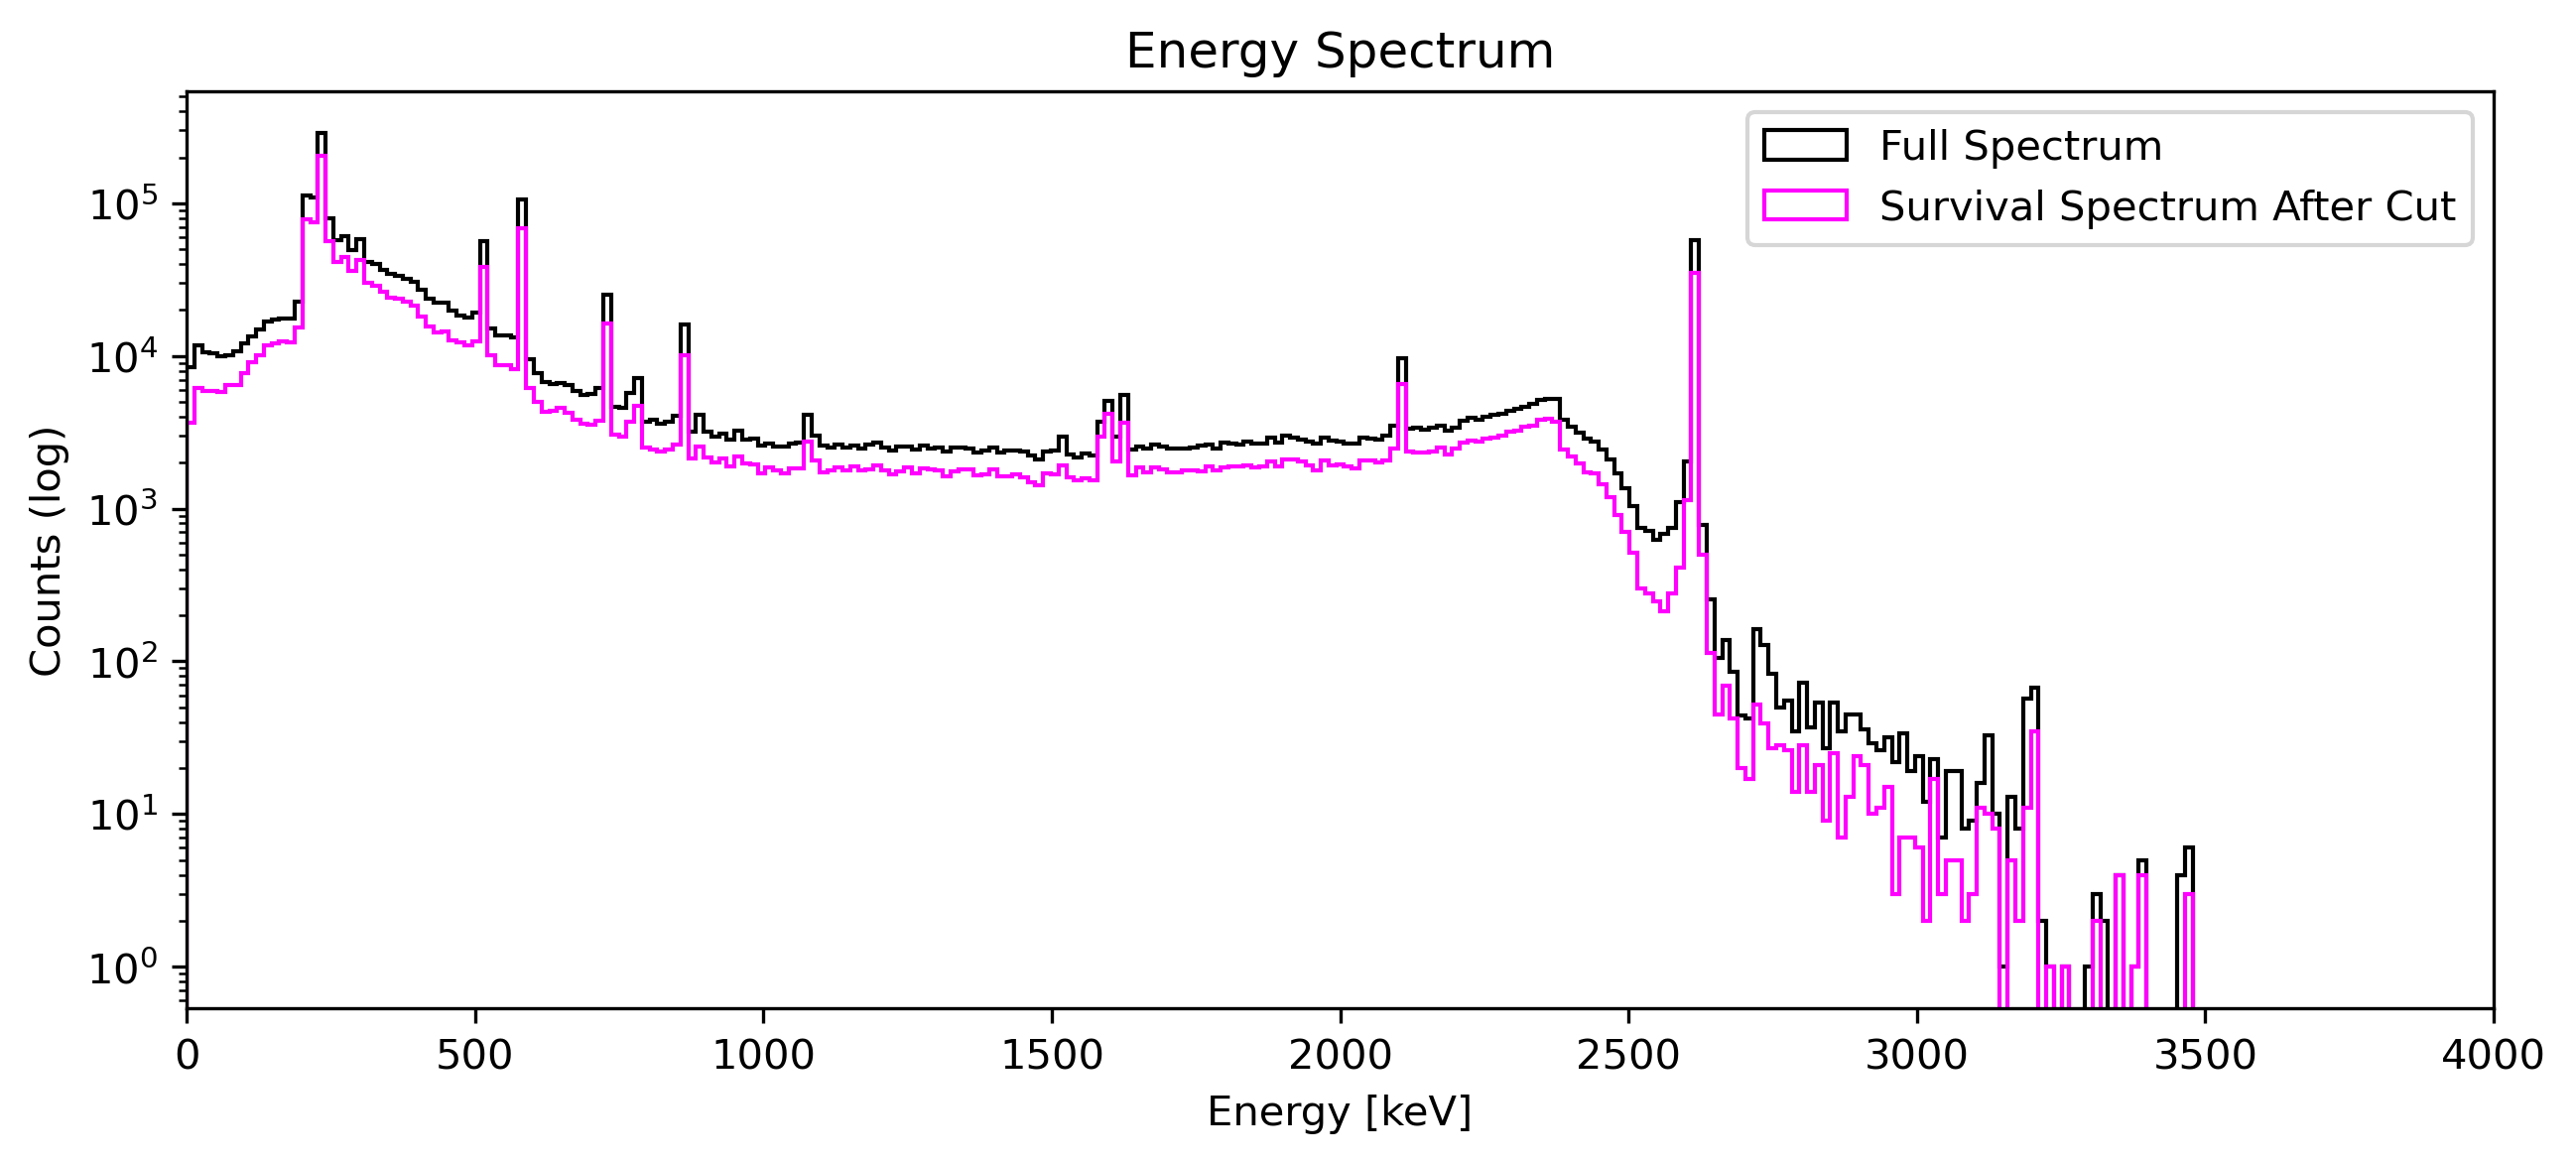

In [76]:

energy_full = y_test_and_train_and_NPML  # Full spectrum
energy_cut = np.concatenate((predictions_NPML_cut_original.reshape(-1),test_and_train_cut))  # Cut spectrum
bins = np.linspace(0, 4000, 300)

plt.figure(figsize=(10, 4),dpi=300)
plt.hist(energy_full, bins=bins, histtype="step", color="black", label="Full Spectrum")
plt.hist(energy_cut, bins=bins, histtype="step", color="magenta", label="Survival Spectrum After Cut")

plt.yscale("log")
plt.xlim(0, 4000)
# Labels and title
plt.xlabel("Energy [keV]")
plt.ylabel("Counts (log)")
plt.title("Energy Spectrum")
plt.legend()

plt.savefig("Energy_Spectrum.png", dpi=300, bbox_inches="tight")

plt.show()


In [69]:
predictions_NPML_cut_original

array([[ 243.96396],
       [1657.2444 ],
       [ 304.63712],
       ...,
       [ 531.6253 ],
       [ 720.76636],
       [1584.5355 ]], dtype=float32)

In [71]:
len(train_df['energylabel'].values),len(test_df['energylabel'].values),len(predictions_NPML_original)

(1689965, 389994, 159696)

In [11]:
len(energy_cut),len(energy_full)

(88378, 159696)

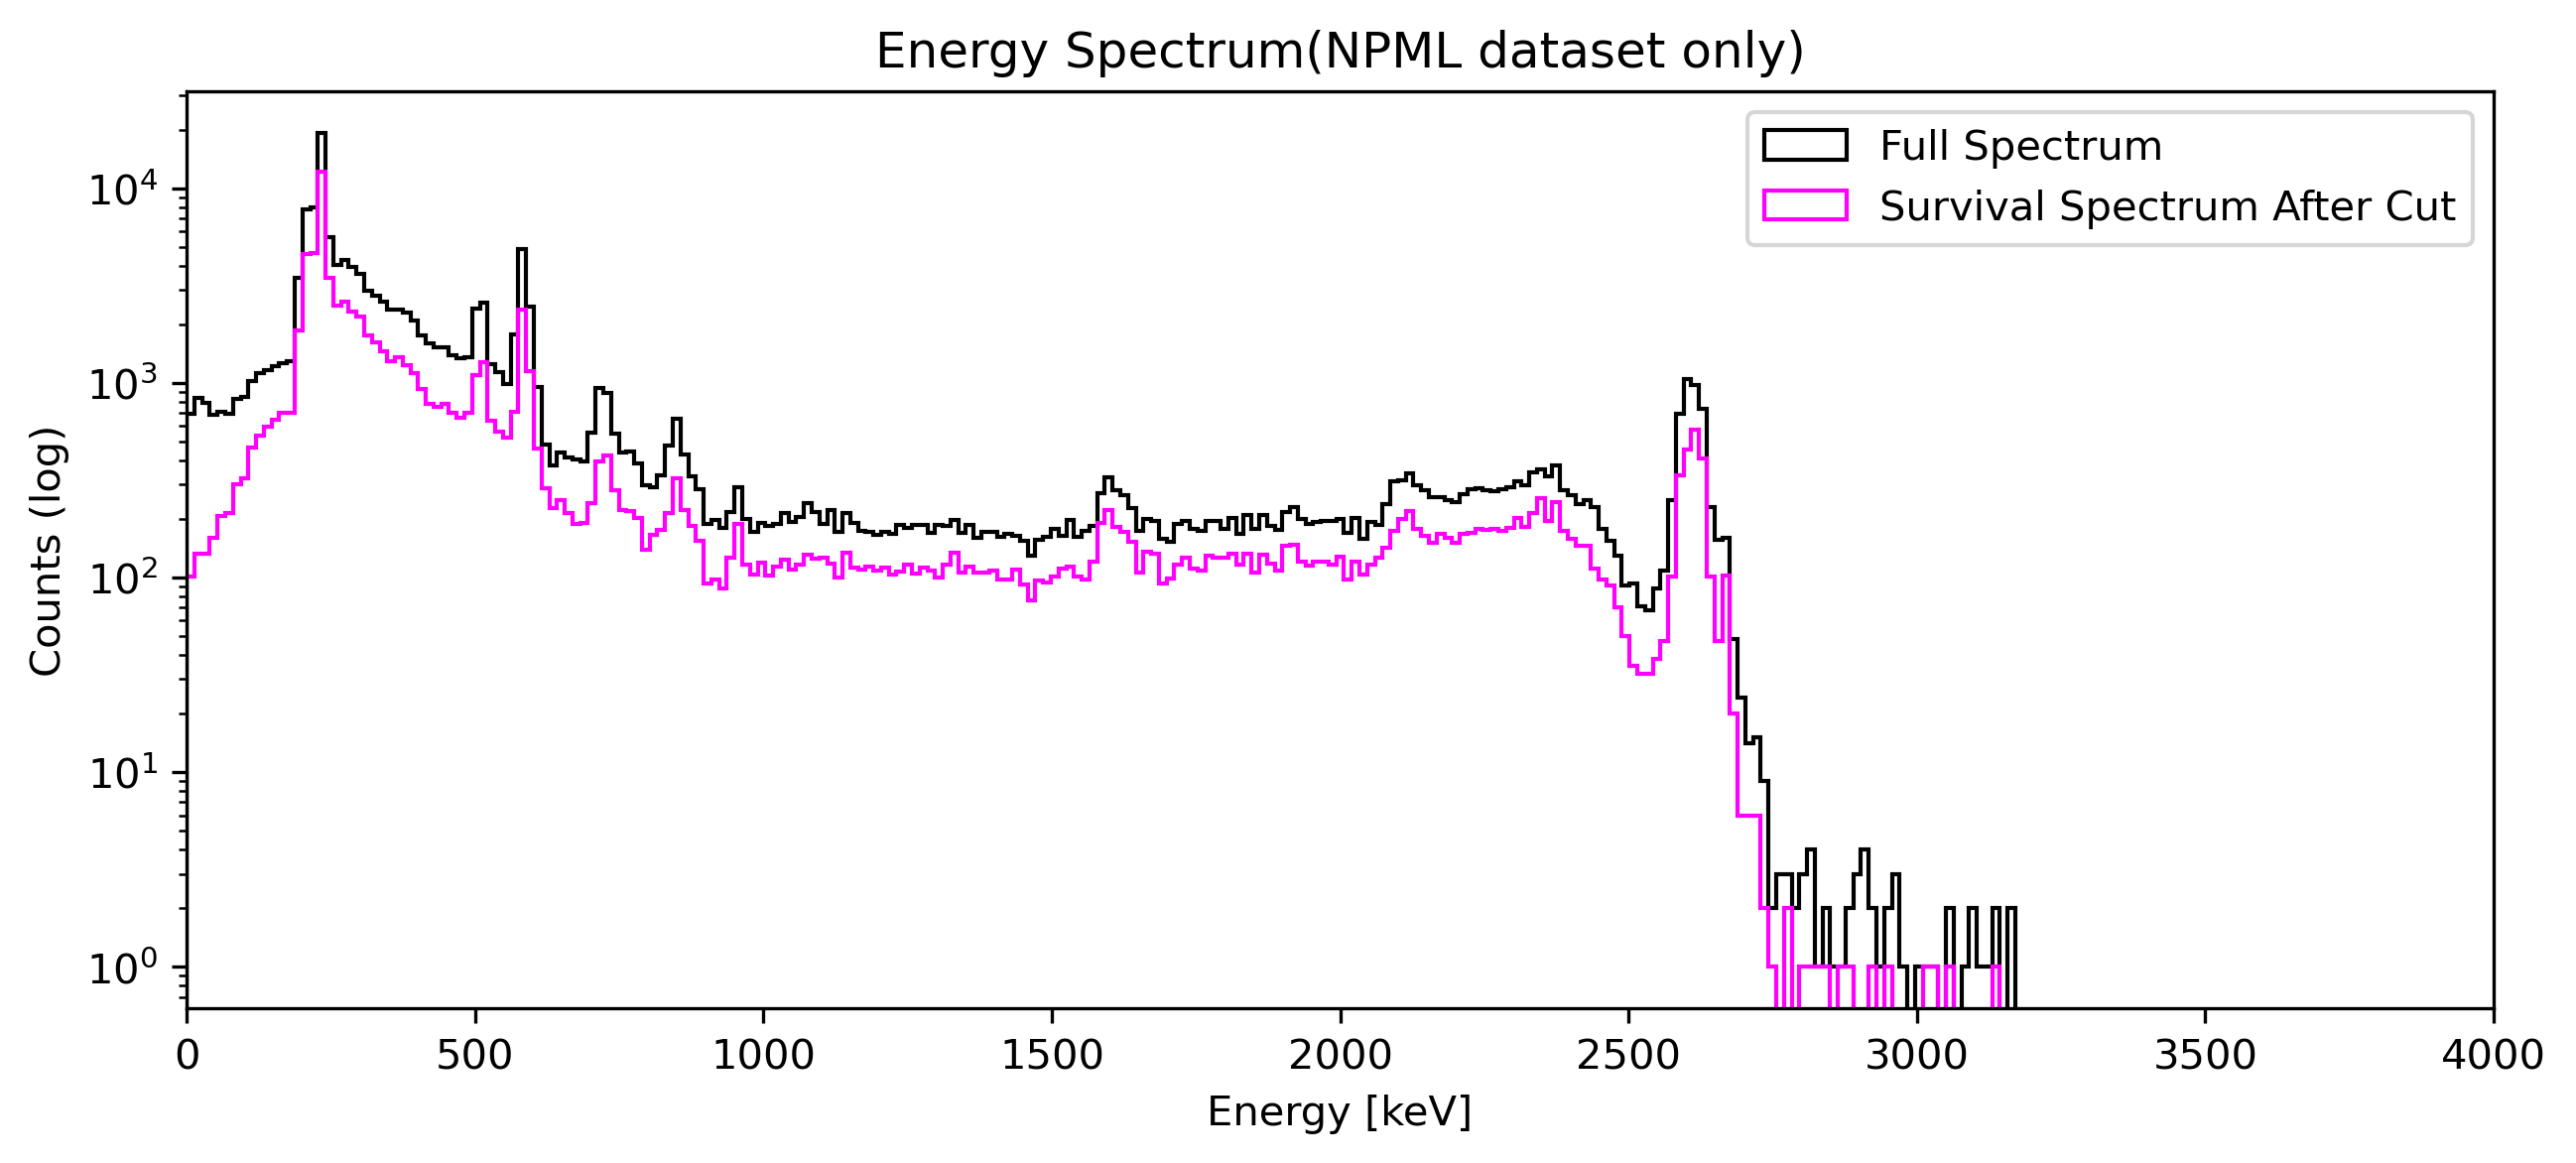

In [10]:

energy_full = predictions_NPML_original  # Full spectrum
energy_cut = predictions_NPML_cut_original  # Cut spectrum
bins = np.linspace(0, 4000, 300)

plt.figure(figsize=(10, 4),dpi=300)
plt.hist(energy_full, bins=bins, histtype="step", color="black", label="Full Spectrum")
plt.hist(energy_cut, bins=bins, histtype="step", color="magenta", label="Survival Spectrum After Cut")

plt.yscale("log")
plt.xlim(0, 4000)
# Labels and title
plt.xlabel("Energy [keV]")
plt.ylabel("Counts (log)")
plt.title("Energy Spectrum(NPML dataset only)")
plt.legend()

plt.savefig("Energy_Spectrum_NPML_only.png", dpi=300, bbox_inches="tight")

plt.show()


In [17]:
np.save('predictions_NPML_cut_original.npy',predictions_NPML_cut_original)

In [18]:
np.save('predictions_NPML_original.npy',predictions_NPML_original)

In [22]:
NPML_cut_df

,tdrift,rea,dcr,peakindex,peakvalue,tailslope,currentamp,lfpr,lq80,areagrowthrate,inflection point,risingedgeslope
4,95.904,0.806482,3.080030e+05,1048,651.0,-0.057811,0.005508,0.017981,65933.0,-273412.0,324,7.679558
5,123.876,1.648333,1.735847e+06,1090,4197.0,-0.390518,0.007440,0.020745,231249.0,-1897374.0,315,29.034052
6,99.900,1.491345,3.559872e+05,1050,844.0,-0.068931,0.005345,0.023162,113615.0,-341986.0,327,6.909205
7,124.875,1.418168,2.952572e+05,1054,686.0,-0.054620,0.005573,0.021739,107245.0,-262569.0,382,4.558255
8,114.885,1.066913,2.650152e+05,1049,743.0,-0.053453,0.005072,0.017822,191027.0,-252230.0,328,5.511560
...,...,...,...,...,...,...,...,...,...,...,...,...
159681,91.908,1.022303,1.151945e+06,1058,2557.0,-0.231814,0.004541,0.020273,145287.0,-1150052.0,314,29.826326
159682,125.874,0.475891,2.928008e+05,1051,685.0,-0.055601,0.006111,0.020711,127036.0,-253489.0,335,6.398803
159685,76.923,0.648722,6.382518e+05,1040,1402.0,-0.122663,0.006581,0.018843,129230.0,-607133.0,339,21.903544
159691,84.915,0.646862,8.554475e+05,1050,1868.0,-0.169065,0.006413,0.019633,146799.0,-823513.0,310,27.041196
